This is an attempt to drastically speed up the drizzle-like approach from [single_forward_model4_build2d.ipynb](single_forward_model4_build2d.ipynb) using CuPy custom kernels, following the struggles of regular JAX in [jax_build2d.ipynb](jax_build2d.ipynb).  Note, all data are fake but of comparable dimension.

In [1]:
import time

from matplotlib import pyplot as plt

import numpy as np
import cupy as cp

# Mock data

Make fake "data" of a dimensionality that's not crazy, and populate it with some random nans

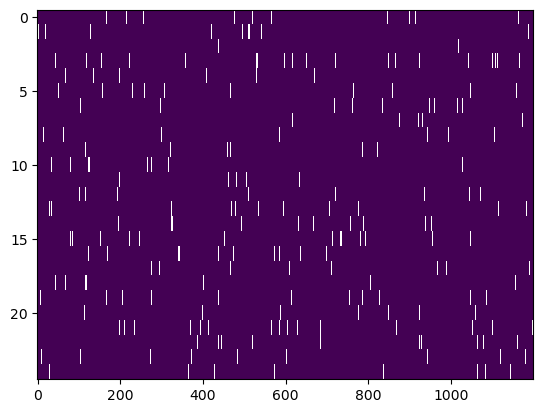

In [2]:
slit = np.zeros((25, 1200))

nanmsk = np.random.uniform(size=slit.shape)>.98

slit[nanmsk] = np.nan*slit[nanmsk]

plt.imshow(slit,aspect='auto', interpolation='nearest')

Make a fake spectrum that's somewhat denser than the "data"

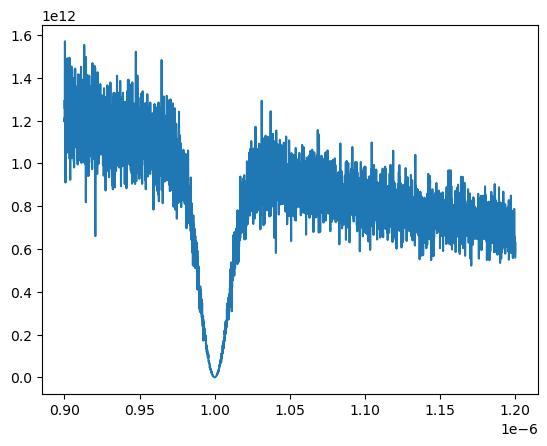

In [3]:
wave_m = np.linspace(0.9e-6, 1.2e-6, 4096)
spectrum = np.ones_like(wave_m)

# this spectrum is artificially noisy with a single bit aborption line.
spectrum = spectrum + 0.1 * np.random.normal(size=spectrum.shape)
spectrum = spectrum * (1-np.exp(-0.5*((wave_m - 1.e-6)/10e-9)**2))
spectrum_fnu = spectrum  * wave_m**-2

plt.plot(wave_m, spectrum_fnu)

Make a fake slightly noisy psf that is ~200x200 with 10x oversampling

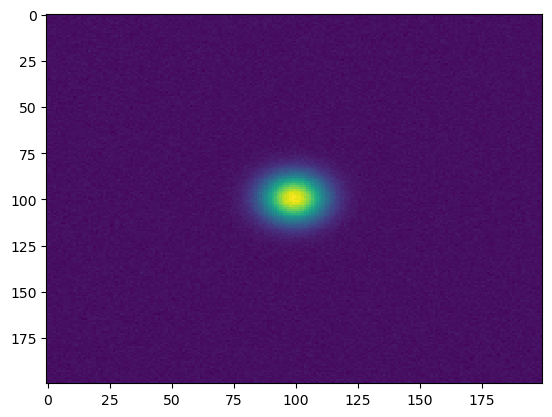

In [4]:
psf_box = (20,20)
oversampling = 10

psfcen_x = psfcen_y = 0

ys, xs = np.indices((psf_box[0]*oversampling, psf_box[1]*oversampling)).astype(float)
ys -= (ys.shape[0]-1)/2
xs -= (xs.shape[1]-1)/2

psf_x = (xs - psfcen_x)/oversampling
psf_y = (ys - psfcen_y)/oversampling

os_psf = np.exp(-0.5*(psf_x**2 + psf_y**2)/(.9**2))

os_psf = os_psf + 0.01 * np.random.normal(size=os_psf.shape)

plt.imshow(os_psf, aspect='auto', interpolation='nearest')

And now make a spectral trace that's curvy

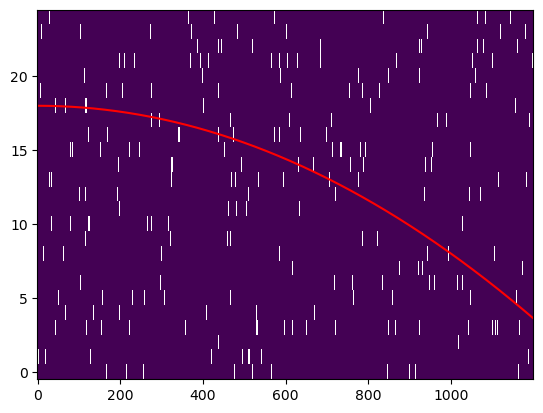

In [5]:
def tracefunc(x):
    return 18 - 10*(x/1000)**2

xtrace = np.arange(slit.shape[1])
ytrace = tracefunc(xtrace)

plt.imshow(slit,aspect='auto', interpolation='nearest', origin='lower')
plt.plot(xtrace, ytrace, color='red')

Note the biggest difference is that the real data have a lot more nans, but this smattering should be sufficient to catch relevant bugs.

In [22]:
xspec = cp.arange(wave_m.size)/wave_m.size * slit.shape[1]
yspec = tracefunc(xspec)

# Algorithmic experimentation

First, pre-compute the influence - i.e. which spectral indecies influence a particular output pixel.

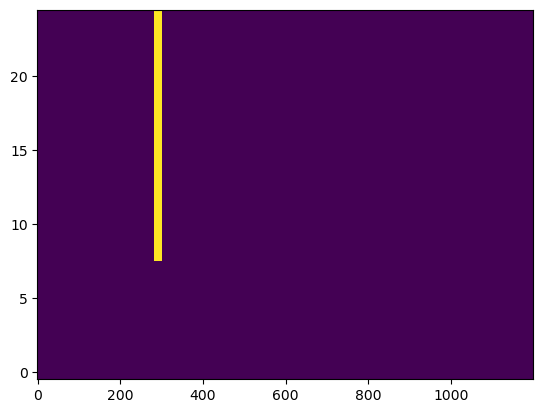

In [37]:
y, x = cp.indices(slit.shape)
maxpsf = max(np.max(psf_x), np.max(psf_y))

dy = cp.subtract.outer(y, yspec)
dx = cp.subtract.outer(x, xspec)

isinfluenced = (cp.abs(dx) < maxpsf) & (cp.abs(dy) < maxpsf)

plt.imshow(isinfluenced[:,:, 1000].get(). astype(float), aspect='auto', interpolation='nearest', origin='lower')

In [108]:
# this is inefficient but we'll put it in a kernel later

startidx = -np.ones(isinfluenced.shape[:2], dtype=int)
nidxs = -np.ones(isinfluenced.shape[:2], dtype=int)
for i in range(isinfluenced.shape[0]):
    for j in range(isinfluenced.shape[1]):
        idxs = np.where(isinfluenced[i, j])
        if len(idxs[0]) > 0:
            startidx[i, j] = idxs[0][0]
            nidxs[i, j] = len(idxs[0])

            dd, cnts = np.unique(np.diff(idxs[0]), return_counts=True)
            if len(dd) > 1:
                d = {int(di):int(ci) for di, ci in zip(dd, cnts)}
                if d.get(0, -1) < 1 or d.get(1, -1) != 1 or d.get(-1, -1) != 1:
                    print(f"bad idxs for {i}, {j}: {idxs} {d} {dd} {cnts}")


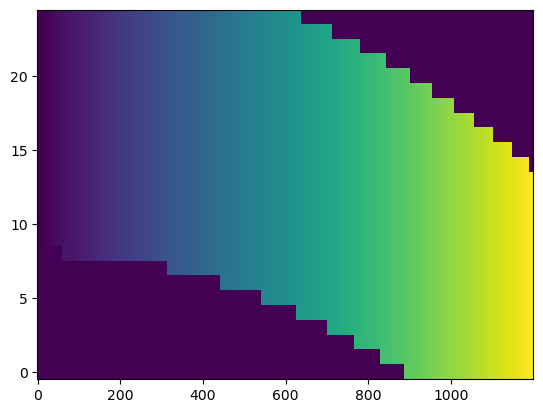

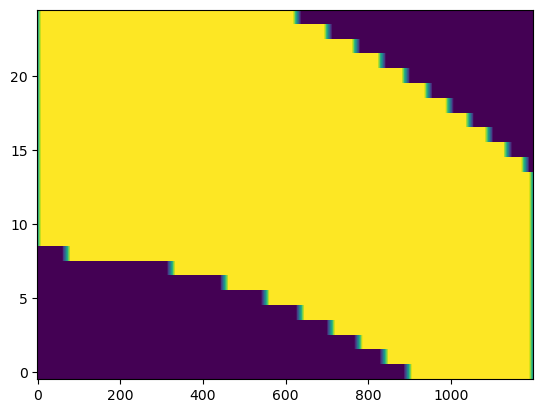

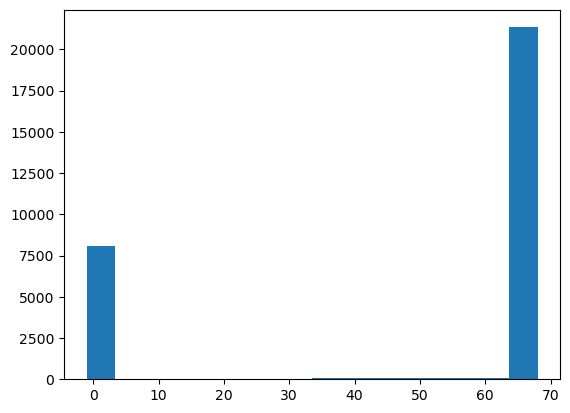

In [110]:
plt.figure()
plt.imshow(startidx, aspect='auto', interpolation='nearest', origin='lower')
plt.figure()
plt.imshow(nidxs, aspect='auto', interpolation='nearest', origin='lower')

plt.figure()
plt.hist(nidxs.ravel(), bins='auto');

Now the algorithm is:

grid over the output pixels

for each of those pixels, do something like:
```
val = 0
for psf_x, psf_y, psf_flux:
    dx = psf_x + xspec
    dy = psf_y + yspec
    o = overlap of dx,dy with opx, ypx
    val += o*psf_flux*fspec
``` 

but most os will be zero.  And since the grid is regular, should be able to compute o as something like
```
dxx = dx - opx
cache_index = int(dxx*ovsersampling % oversampling)
if cache miss for cache_index:
    cache[cache_indx] = compute overlap for dxx % 1
ox = cache[cache_index]
```
(similar for y)

But first try to implement a kernel *without* the caching, nor any clever shared memory tricks.

A natural grid/block dimensionality to try is a grid that is the shape of the slit.  The block size is a free parameter, but it should make the psf size divided by it have as small a remainder as possible while being a multiple of 32.

In [ ]:
kernel = cp.RawKernel("""
extern "C" __global__
void kernel(const float* psffluxs, const float* psfxs, const float* psfys, 
            const float* xspecs, const float* yspecs, const float* fluxspecs,
            const int* startidxs, const int* nidxs,
            float* slit) {
                      

    int outidx = gridDim.x * blockIdx.y + blockIdx.x;
    int startidx = startidxs[outidx];
    int nidx = nidxs[outidx];
                      
    for (int i = startidx; i < nidx; i++) {
        float xspec = xspecs[i];
        float yspec = yspecs[i];
        float fluxspec = fluxspecs[i];
                             
        // TODO: adapt this to the data here
        int stride = gridDim.x * blockDim.x; // Total number of threads in the grid
        int tid = blockIdx.x * blockDim.x + threadIdx.x;

        // Threads jump by 'stride' until the end of the data
        for (int i = tid; i < N; i += stride) {
            data[i] *= 2;
                        
            // define psfidx, loop over enough to complete teh psf
            float psfx = psfxs[psfidx];
            float psfy = psfys[psfidx];
            float psfval = psffluxs[psfidx];
                        
            float x = psfx + xspec;
            float y = psfy + yspec;
                        
            opx = overlap of x with opx
            opy = overlap of y with opy
            
            float contribution = psfval * opx * opy * fluxspec;
            
        }     
    }
          


    // thread 0 of the block writes to global memory
    if (threadIdx.x == 0 && threadIdx.y == 0 && blockIdx.x == 0 && blockIdx.y == 0) {
        slit[outidx] = result;
    }
                      
}
"""[1:-1], 'kernel')

In [111]:
kernel = cp.RawKernel("""
extern "C" __global__
void kernel(const float* x1, const float* x2, float* y) {
    int tid = blockDim.x * blockIdx.x + threadIdx.x;
    y[tid] = x1[tid] + x2[tid];
}
"""[1:-1], 'kernel')